In [1]:
import pandas as pd
import ast
import matplotlib.pyplot as plt


df_pcl = pd.read_csv(
    "Data/dontpatronizeme_pcl.tsv",
    sep="\t",
    header=None,
    skiprows=4,
    names=["par_id", "art_id", "keyword", "country", "text", "label"],
)
train_lbl = pd.read_csv("Data/train_semeval_parids-labels.csv")
dev_lbl = pd.read_csv("Data/dev_semeval_parids-labels.csv")


train_lbl["label_vec"] = train_lbl["label"].apply(ast.literal_eval)
dev_lbl["label_vec"]   = dev_lbl["label"].apply(ast.literal_eval)

train_lbl["y"] = train_lbl["label_vec"].apply(lambda v: int(sum(v) > 0))
dev_lbl["y"]   = dev_lbl["label_vec"].apply(lambda v: int(sum(v) > 0))



In [2]:
train_lbl.head()

,par_id,label,label_vec,y
0,4341,"[1, 0, 0, 1, 0, 0, 0]","[1, 0, 0, 1, 0, 0, 0]",1
1,4136,"[0, 1, 0, 0, 0, 0, 0]","[0, 1, 0, 0, 0, 0, 0]",1
2,10352,"[1, 0, 0, 0, 0, 1, 0]","[1, 0, 0, 0, 0, 1, 0]",1
3,8279,"[0, 0, 0, 1, 0, 0, 0]","[0, 0, 0, 1, 0, 0, 0]",1
4,1164,"[1, 0, 0, 1, 1, 1, 0]","[1, 0, 0, 1, 1, 1, 0]",1


In [3]:
df_pcl.head()

,par_id,art_id,keyword,country,text,label
0,1,@@24942188,hopeless,ph,"We 're living in times of absolute insanity , ...",0
1,2,@@21968160,migrant,gh,"In Libya today , there are countless number of...",0
2,3,@@16584954,immigrant,ie,White House press secretary Sean Spicer said t...,0
3,4,@@7811231,disabled,nz,Council customers only signs would be displaye...,0
4,5,@@1494111,refugee,ca,""" Just like we received migrants fleeing El Sa...",0


In [4]:
train = df_pcl.merge(train_lbl[["par_id","y"]], on="par_id", how="inner")
dev   = df_pcl.merge(dev_lbl[["par_id","y"]],   on="par_id", how="inner")

assert set(train["y"].unique()).issubset({0,1})
assert set(dev["y"].unique()).issubset({0,1})
print("Train size:", len(train), "Dev size:", len(dev))


print(train["y"].value_counts())
print(train["label"].value_counts())



Train size: 8375 Dev size: 2094
y
0    7581
1     794
Name: count, dtype: int64
label
0    6825
1     756
3     369
4     299
2     126
Name: count, dtype: int64


,split,n_total,n_no_pcl (0),n_pcl (1),pcl_rate
0,train,8375,7581,794,0.094806
1,dev,2094,1895,199,0.095033


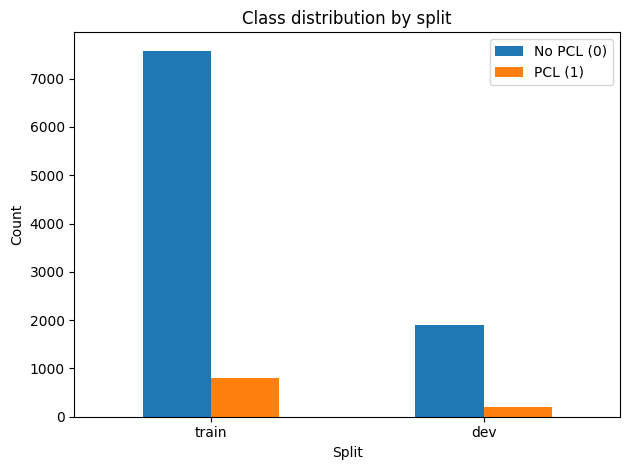

In [6]:
def split_summary(df, name):
    vc = df["y"].value_counts().reindex([0,1]).fillna(0).astype(int)
    total = vc.sum()
    pos_rate = (vc.loc[1] / total) if total > 0 else 0.0
    return pd.DataFrame({
        "split": [name],
        "n_total": [total],
        "n_no_pcl (0)": [vc.loc[0]],
        "n_pcl (1)": [vc.loc[1]],
        "pcl_rate": [pos_rate],
    })

summary = pd.concat([split_summary(train, "train"),
                     split_summary(dev, "dev")], ignore_index=True)

display(summary)

# Plot: label distribution by split
counts = pd.DataFrame({
    "train": train["y"].value_counts().reindex([0,1]).fillna(0),
    "dev": dev["y"].value_counts().reindex([0,1]).fillna(0),
}).T
counts.columns = ["No PCL (0)", "PCL (1)"]

ax = counts.plot(kind="bar")
plt.title("Class distribution by split")
plt.xlabel("Split")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

,keyword,n,pcl_rate
1,homeless,865,0.172254
4,in-need,856,0.167056
6,poor-families,719,0.155772
2,hopeless,788,0.124365
7,refugee,880,0.082955
0,disabled,834,0.080336
8,vulnerable,871,0.068886
9,women,837,0.045400
5,migrant,882,0.035147
3,immigrant,843,0.027284


,keyword,n,pcl_rate
3,immigrant,843,0.027284
5,migrant,882,0.035147
9,women,837,0.045400
8,vulnerable,871,0.068886
0,disabled,834,0.080336
7,refugee,880,0.082955
2,hopeless,788,0.124365
6,poor-families,719,0.155772
4,in-need,856,0.167056
1,homeless,865,0.172254


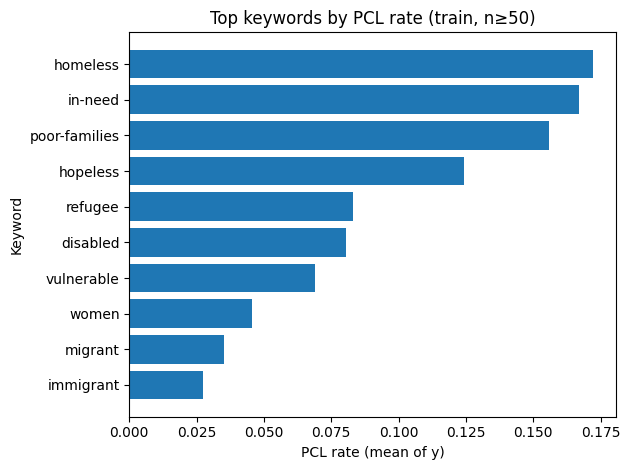

In [5]:
# Compute PCL rate per keyword in train
kw_stats = (
    train.groupby("keyword")["y"]
    .agg(n="count", pcl_rate="mean")
    .reset_index()
)

# Filter to keywords with enough samples so rates are meaningful
MIN_N = 50
kw_stats_f = kw_stats[kw_stats["n"] >= MIN_N].copy()

# Show extremes: highest PCL rate keywords
top_high = kw_stats_f.sort_values(["pcl_rate", "n"], ascending=[False, False]).head(15)
top_low  = kw_stats_f.sort_values(["pcl_rate", "n"], ascending=[True, False]).head(15)

display(top_high)
display(top_low)

# Plot the top-high keywords
plot_df = top_high.sort_values("pcl_rate", ascending=True)  # so bars go low->high
ax = plt.barh(plot_df["keyword"], plot_df["pcl_rate"])
plt.title(f"Top keywords by PCL rate (train, n≥{MIN_N})")
plt.xlabel("PCL rate (mean of y)")
plt.ylabel("Keyword")
plt.tight_layout()
plt.show()